#  Logistic Regression & Classification Metrics

<hr style="height: 5px; background-color: pink ; border: none;">

### Introduction 

In the previous notebook, we learned about **Linear Regression**, which is used to predict continuous values. However, not every machine learning problem involves continuous targets. In many real-world scenarios, the target variable is categorical rather than numerical.

In this notebook, we will explore **Logistic Regression**, a supervised learning algorithm used for classification tasks. Instead of predicting continuous values, logistic regression predicts the probability that a data point belongs to a particular category, making it suitable for problems with categorical target variables.


<hr style="height: 5px; background-color: pink ; border: none;">

# Section 1 : How Logistic Regression Works

## 1.1 What is it used for ?



**Logistic Regression** is mainly used for **classification** problems. Classification is the task of assigning data points to one of several predefined categories or classes based on their input features. The two most common types of classification are 

- **binary classification :** where the target variable has two possible classes
- **multiclass classification :** where the target variable has more than two  classes.

In this notebook, we will focus more on Binary Classification

## 1.2 Binay Classification


Logistic regression is used for binary classification
problems, where the output is either 0 or 1. The model takes an input vector X, which
represents the features of the data, such as the pixel values of an image.
Instead of directly predicting 0 or 1, logistic regression outputs a value called y_hat,
which represents the probability that the output is 1. In other words, the model estimates
how likely it is that the input belongs to the positive class.

## 1.3 Weights and Model Computation

### First step : linear combination 
Just like **Linear Regression**, Logistic Regression uses a set of parameters called **weights** ($W$) and a **bias** ($b$) to compute its output. Each weight corresponds to one feature in the input vector $X$ and represents the influence of that feature on the model's prediction.

The weights are stored in a column vector $W$. When we take its transpose ($W^T$), it becomes a row vector, allowing it to be multiplied with the input vector $X$ using matrix multiplication.

**The model first computes a linear combination of the input features using the following equation:**

<span style="font-size: 20px;">$$z = W^T X + b$$</span>


 In Logistic Regression, however, this value is **not** the final prediction. Instead, it is passed through the **sigmoid function**, which converts it into a probability that can be used for classification.
> 
>  <div style="text-align: center;"> <img src="Linear_Output_Pre_Activation.PNG" alt="A descriptive summary of the photo" width="500" > </div>

--- 

### Second step: Activation Function (Sigmoid )

Just like Linear Regression, Logistic Regression uses a set of parameters called weights ($W$) and a bias ($b$) to compute its output. Each weight corresponds to one feature in the input vector $X$ and represents the influence of that feature on the model's prediction.

The weights are stored in a column vector $W$. When we take its transpose ($W^T$), it becomes a row vector, allowing it to be multiplied with the input vector $X$ using matrix multiplication.

**sigmoid function formula :**
<span style="font-size: 20px;">$$f(x) = \frac{1}{1 + e^{-z}}$$</span>
**where:**

- $f(x)$ is the output of the sigmoid function.
- $e$ is Euler's number: a mathematical constant ≈ 2.71828.
- $z$ is the input to the sigmoid function( The z linear value we got from the linear equation )


**Output of Sigmoid :** The sigmoid function maps any real-valued input to a value between 0 and 1. This output is interpreted as the probability that a data point belongs to the positive class. A value close to 0 indicates a low probability, while a value close to 1 indicates a high probability. A threshold (commonly 0.5) is then used to assign the final class label.

**How linear output is transformed to logistic regression output using these calculations:**
>  <div style="text-align: center;"> <img src="Transformation.PNG" alt="A descriptive summary of the photo" width="600" > </div>


#### Final prediction (0 or 1).
---


### Summary of the process

>  <div style="text-align: center;"> <img src="Flow.PNG" alt="A descriptive summary of the photo" width="500" > </div>


## 1.4 Linear Regression Vs Logistic Regression 

| Aspect | Linear Regression | Logistic Regression |
|--------|-------------------|---------------------|
| **Purpose** | Predicts **continuous numerical values**. | Predicts the **probability of a class** for classification tasks. |
| **Output Range** * | Can produce **any real value** ($-\infty$ to $+\infty$). | Produces values **between 0 and 1**, making them valid probabilities. |
| **Relationship Between Input and Output** | The output changes **linearly** as the input increases. | The output follows an **S-shaped (sigmoid) curve**, gradually approaching 0 or 1. |
| **Activation Function** | No activation function is applied. | Uses the **sigmoid function** to transform the linear output into a probability. |
| **Suitable For** | Regression problems with **continuous target variables**. | Classification problems with **categorical target variables**, especially binary classification. |
| **Example** | Predicting house prices or temperatures. | Predicting whether an email is spam or not, or whether a patient has a disease. |

<hr style="height: 5px; background-color: pink ; border: none;">

# Section 2 : Training the Model

## 1) Load a dataset from sklearn then split it into a training set and testing set.

The Breast Cancer Wisconsin Dataset is the most popular built-in toy dataset in Scikit-Learn natively designed for binary classification

In [2]:
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 


# Load as a dictionary
data = load_breast_cancer()
X, y = data.data, data.target

# split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 2) Import the Logistic Regression model, fit the data, and compute the activation function

> ### Training a Logistic Regression Model


### Code Syntax

- **`from sklearn.linear_model import LogisticRegression`** :  Imports the  logistic regression model 

- **`model = LogisticRegression(max_iter=4000)`** :  Creates an instance of the logistic regression model.
  >   - `max_iter=4000` specifies the maximum number of iterations the optimization algorithm is allowed to perform while finding the best model parameters.
  >   - Increasing this value helps the model converge, especially for larger or more complex datasets.

- **`model.fit(X_train, y_train)`**
  
  Trains (fits) the logistic regression model using the training data.
  
  - `X_train` contains the input features.
  - `y_train` contains the corresponding target labels.
  
  During training, the model learns the optimal weights and bias that best separate the classes.

- **`predictions = model.predict(X_test)`**
  
  Uses the trained model to predict the class label for each sample in the test set.
  
  The returned values are the predicted classes (e.g., `0` or `1` for binary classification).

- **`probabilities = model.predict_proba(X_test)`**
  
  Computes the predicted probability for each possible class instead of only returning the predicted label.
  
  - Each row corresponds to one sample.
  - Each column represents the probability of belonging to a particular class.
  - For binary classification, the first column contains the probability of class `0`, and the second column contains the probability of class `1`.



In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=4000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test) # class probabilities
print(predictions)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


E:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


> **Note:** During the training of the Logistic Regression model, the following warning appeared:
> `ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s)`

This warning means that the optimization algorithm (**lbfgs**) could not find the best model parameters before reaching the maximum number of iterations (`max_iter=4000`). This often happens when the input features have **very different scales** (for example, one feature ranges from `0–1` while another ranges from `0–10000`).

**How to fix it:**
- Increase the value of `max_iter`.
- **Scale the data** using methods such as `StandardScaler` or `MinMaxScaler`.

**What does “data is not scaled” mean?**
It means that the features are measured in different numerical ranges, which can make it harder for the optimization algorithm to converge efficiently.

In [4]:
# Same code as above but using a scaler


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=4000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test) # class probabilities
print(predictions)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


<hr style="height: 5px; background-color: pink ; border: none;">

# Section 3 : Evaluating the Model

> Model evaluation is the process of assessing how well a machine learning model performs on unseen data using different metrics and techniques. It ensures that the model not only memorises training data but also generalises to new situations. By applying various techniques, we can identify whether a model has truly learned patterns or not.
>
### Here we are exploring the following Evaluation Metrics:

- Confusion Matrix
- Precision
- Recall
- F1-score
- ROC Curve
- AUC

## 3.1 Accuracy

Accuracy shows how many predictions the model got right out of all the predictions. It gives idea of overall performance but it can be misleading when one class is more dominant over the other. For example a model that predicts the majority class correctly most of the time might have high accuracy but still fail to capture important details about other classes. It can be calculated using the below formula:[1]

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$

An accuracy of **90%** means that the model correctly classified 90 out of every 100 samples.

### Why Isn't Accuracy Alone Enough?

For example, if 95% of emails are **not spam**, a model that always predicts **"Not Spam"** will achieve **95% accuracy**, even though it completely fails to detect spam emails.

For this reason, accuracy should be used together with other evaluation metrics, such as the **Confusion Matrix**, **Precision**, **Recall**, and **F1-score**, which provide a more complete picture of a model's performance.

## 3.2 Confusion Matrix

> Confusion matrix is a simple table used to measure how well a classification model is performing. It compares the predictions made by the model with the actual results and shows where the model was right or wrong. This helps you understand where the model is making mistakes so you can improve it. It breaks down the predictions into four categories:
>
- **True Positive (TP):** The model correctly predicted a positive outcome i.e the actual outcome was positive.
- **True Negative (TN):** The model correctly predicted a negative outcome i.e the actual outcome was negative.
- **False Positive (FP):** The model incorrectly predicted a positive outcome i.e the actual outcome was negative. It is also known as a Type I error.
- **False Negative (FN):** The model incorrectly predicted a negative outcome i.e the actual outcome was positive. It is also known as a Type II error

>  <div style="text-align: center;"> <img src="CM.PNG" alt="A descriptive summary of the photo" width="400" > </div>


#### Visualizing the Confusion Matrix

```python
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Malignant", "Benign"],
    cmap="Blues"
)

plt.show()
```

#### Code Syntax

- **`from sklearn.metrics import ConfusionMatrixDisplay`**

  Imports the `ConfusionMatrixDisplay` class, which provides an easy way to visualize a confusion matrix.

- **`import matplotlib.pyplot as plt`**

  Imports Matplotlib, which is used to display the generated plot.

- **`ConfusionMatrixDisplay.from_predictions(y_test, predictions)`**

  Creates a confusion matrix directly from the true labels (`y_test`) and the predicted labels (`predictions`), then generates a visualization.

- **`display_labels=["Malignant", "Benign"]`**

  Replaces the default class labels (`0` and `1`) with more meaningful names on the axes.

- **`cmap="Blues"`**

  Applies the **Blues** color map, where darker shades represent higher counts in the confusion matrix.

- **`plt.show()`**

  Displays the confusion matrix figure.

In [21]:
# This code right here is to check the classes name in the sklearn Diabetes dataset , make sure to go and run the code cells in Section 2

display_labels=data.target_names
print(display_labels)

['malignant' 'benign']


[[41  2]
 [ 1 70]]


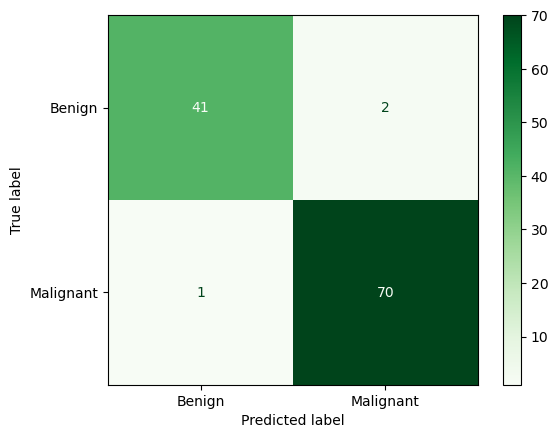

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Benign", "Malignant"],  
    cmap="Greens"
)
plt.show()


## 3.3 Precision

> It measures how many of the positive predictions made by the model are actually correct. It's useful when the cost of false positives is high such as in medical diagnoses where predicting a disease when it’s not present can have serious consequences.
>
> 
$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

 Where:

- TP = True Positives
- FP = False Positives

> #### Precision helps ensure that when the model predicts a positive outcome, it’s likely to be correct.

## 3.4 Recall

> Recall or Sensitivity measures how many of the actual positive cases were correctly identified by the model. It is important when missing a positive case (false negative) is more costly than false positives.
>
$$\text{Recall} = \frac{TP}{TP + FN}$$

Where:

- FN = False Negatives
  
> #### In scenarios where catching all positive cases is important (like disease detection), recall is a key metric.

## 3.5  F1 Score

> The F1 Score is the harmonic mean of precision and recall. It is useful when we need a balance between precision and recall as it combines both into a single number. A high F1 score means the model performs well on both metrics. Its range is [0,1].

Lower recall and higher precision gives us great accuracy but then it misses a large number of instances. More the F1 score better will be performance. It can be expressed mathematically in this way:
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

## 3.6  Logarithmic Loss (Log Loss)

> Log loss measures the uncertainty of the model’s predictions. It is calculated by penalizing the model for assigning low probabilities to the correct classes. This metric is used in multi-class classification and is helpful when we want to assess a model’s confidence in its predictions.
>
 If there are N  samples belonging to the M class, then we calculate the Log loss in this way:

 $$L = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

Where:

- $y_{ij}$ = Actual class (0 or 1) for sample $i$ and class $j$.
- $p_{ij}$ = Predicted probability for sample $i$ and class $j$.

 > #### The goal is to minimize Log Loss, as a lower Log Loss shows higher prediction accuracy.

## 3.7  Area Under Curve (AUC) and ROC Curve


>  The **AUC-ROC (Area Under the Receiver Operating Characteristic Curve)** is a metric used to evaluate the performance of a classification model across different classification thresholds.

The ROC curve shows the trade-off between:
- **True Positive Rate (Recall):** The proportion of actual positive cases correctly identified.
- **False Positive Rate:** The proportion of negative cases incorrectly classified as positive.

The **AUC value** summarizes the ROC curve into a single score:

- An AUC of **0.5** indicates a model that performs no better than random guessing.
- An AUC close to **1.0** indicates a model that can effectively distinguish between classes.

>  <div style="text-align: center;"> <img src="ROC.PNG" alt="A descriptive summary of the photo" width="400" > </div>


### Computing AUC-ROC

```python
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probabilities)

print("AUC-ROC:", auc)
```

### Interpretation

In our model above, the AUC-ROC score indicates how well the model can distinguish between people with diabetes and people without diabetes. A higher AUC means that the model is better at ranking positive cases above negative cases.


## 3.8 Evaluation Metrics Syntax

In [4]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



<hr style="height: 5px; background-color: pink ; border: none;">

# Section 4 : Hands-on Lap

In this section, we will build a classification model using the Diabetes dataset from Scikit-learn. The goal is to train a Logistic Regression classifier that predicts whether a person has diabetes or not.

The target variable is binary, where:

- 0 represents that the person does not have diabetes.
- 1 represents that the person has diabetes.

After training the model, we will evaluate its performance using classification metrics, including the confusion matrix, to understand how well the model is able to classify the two classes.

## Step 1: Train a LogisticRegression model on a provided classification dataset.


> Using the same code from Section 2

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=4000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test) # class probabilities
print(predictions)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


## Step 2: Generate predictions and produce the confusion matrix.

[[41  2]
 [ 1 70]]


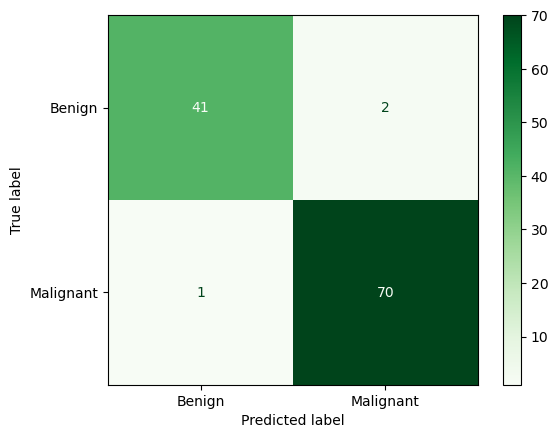

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

print(confusion_matrix(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Benign", "Malignant"],  
    cmap="Greens"
)
plt.show()

#### Analysing Confusion Matrix results:
- True Negatives (TN = 41): The model correctly predicted 41 people as not having diabetes.
- False Positives (FP = 2): The model incorrectly predicted 2 people as having diabetes, while they actually did not.
- False Negatives (FN = 1): The model missed 1 person with diabetes by predicting that they did not have the disease.
- True Positives (TP = 70): The model correctly identified 70 people as having diabetes.

### The model performed well with very few incorrect predictions. It correctly classified most samples and only missed one actual diabetes case

## Step 3: Compute precision, recall, and F1 with classification_report, and interpret each.

In [26]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### Classification Report Analysis

### Class 0 (No Diabetes)

- **Precision = 0.98:** Out of all samples predicted as class 0, **98% were correctly classified as not having diabetes**. Only a small number of predictions were false positives.
- **Recall = 0.95:** The model correctly identified **95% of all actual class 0 samples**. This means that a small number of people without diabetes were incorrectly classified.
- **F1-score = 0.96:** The model achieved a strong balance between precision and recall for class 0.

### Class 1 (Diabetes)

- **Precision = 0.97:** Out of all samples predicted as having diabetes, **97% were actually diabetic**.
- **Recall = 0.99:** The model correctly detected **99% of actual diabetes cases**, meaning it missed very few positive cases.
- **F1-score = 0.98:** The high F1-score shows that the model performs very well in identifying people with diabetes while maintaining few incorrect predictions.

###  Performance

The model achieved an **accuracy of 97%**, meaning it correctly classified 97% of the total samples.

The **macro average** and **weighted average** F1-scores are both **0.97**, whcich means that the model performs consistently well across both classes. In particular, the high recall for class 1 is important because it means the model successfully identifies most diabetes cases and produces very few false negatives.

## Step 4: Decide whether precision or recall matters more for this specific problem and justify it.


Both **precision** and **recall** are important because the model is used for medical diagnosis.

In medical diagnosis, failing to correctly identify a case can be very costly. A person who actually has a disease but is predicted as healthy may not receive the necessary diagnosis or treatment on time.

- **Precision → "When the model predicts that a person has diabetes, how often is that prediction correct?"**  
  Precision is concerned with avoiding **false alarms (false positives)**, where a person is incorrectly classified as having diabetes even though they do not.

- **Recall → "Did the model identify all the people who actually have diabetes?"**  
  Recall is concerned with avoiding **missed cases (false negatives)**, where a person who has diabetes is incorrectly classified as not having it.


## Step 5 : Compute the AUC-ROC and document what it says about the model.

In [27]:
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probabilities)

print("AUC-ROC:", auc)

AUC-ROC: 0.99737962659679


### Explaining results:
> We got a very high AUC value of 0.99737962659679 , which means the model can distinguish between people with diabetes and people without diabetes very well.

<hr style="height: 5px; background-color: pink ; border: none;">

# Referencees

[1] what is accurecy : https://www.geeksforgeeks.org/machine-learning/machine-learning-model-evaluation/

Evaluation Metrics in Machine Learning : https://www.geeksforgeeks.org/machine-learning/metrics-for-machine-learning-model/

Read nore about  AUC-ROC : https://www.geeksforgeeks.org/machine-learning/metrics-for-machine-learning-model/